In [ ]:
import pandas as pd
import os

# Define the folder path containing the data files
folder_path = "Traduction avis clients"

# List all Excel files (.xlsx or .xls) in the folder
all_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx') or f.endswith('.xls')]
# Print the number of files found and display the first 5 files
print(f"find {len(all_files)} file")
print(all_files[:5])

find 35 file
['avis_33_traduit.xlsx', 'avis_34_traduit.xlsx', 'avis_21_traduit.xlsx', 'avis_26_traduit.xlsx', 'avis_10_traduit.xlsx']


 ## Data Cleaning

In [ ]:
# Read all Excel files and combine them into a single DataFrame
dfs = []
for f in all_files:
    df = pd.read_excel(os.path.join(folder_path, f))
    dfs.append(df)

# Concatenate all dataframes
data = pd.concat(dfs, ignore_index=True)
print(data.shape)
print(data.columns.tolist())
print(data.head(3))

(34435, 11)
['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']
   note         auteur                                               avis  \
0   NaN  estelle-51227  j'ai quitté mon ancien contrat d'assurance che...   
1   NaN   leadum-51107  j'ai souscrit à cette mutuelle l'année dernier...   
2   NaN    enora-49520  Impossible d'avoir le bon service , ils raccro...   

         assureur produit  type date_publication    date_exp  \
0  Néoliane Santé   sante  test       12/01/2017  01/01/2017   
1  Néoliane Santé   sante  test       09/01/2017  01/01/2017   
2  Néoliane Santé   sante  test       24/11/2016  01/11/2016   

                                             avis_en avis_cor avis_cor_en  
0  I left my former insurance contract at General...      NaN         NaN  
1  I subscribed to this mutual a year last year a...      NaN         NaN  
2  Impossible to have the right service, they han...      NaN     

In [ ]:
# Check data types, missing values, and rating distribution
print(data.dtypes)
print("\n Missing Value: ")
print(data.isnull().sum())
print("\nnote distribution：")
print(data['note'].value_counts())

note                float64
auteur                  str
avis                    str
assureur                str
produit                 str
type                    str
date_publication        str
date_exp                str
avis_en                 str
avis_cor             object
avis_cor_en          object
dtype: object

 Missing Value: 
note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

note distribution：
note
1.0    7271
4.0    4885
5.0    4850
2.0    3716
3.0    3382
Name: count, dtype: int64


In [ ]:
# Remove rows with missing rating values and convert ratings to integers
data_clean = data.dropna(subset=['note']).copy()
data_clean['note'] = data_clean['note'].astype(int)

print(data_clean.shape)
print(data_clean['note'].value_counts().sort_index())

(24104, 11)
note
1    7271
2    3716
3    3382
4    4885
5    4850
Name: count, dtype: int64


In [ ]:
import re

# Define a text cleaning function: lowercase, remove special characters, normalize whitespace
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning to both French and English reviews
data_clean['avis_clean'] = data_clean['avis'].apply(clean_text)
data_clean['avis_en_clean'] = data_clean['avis_en'].apply(clean_text)

print(data_clean['avis_clean'].head(3))

2000    les prix au top la facilité d inscription et l...
2001    je n ai pas les moyens d attendre 3 à 4 semain...
2002    je voulais assurer une tesla modèle 3 lr le pr...
Name: avis_clean, dtype: str


In [ ]:
# Save cleaned data to CSV file
data_clean.to_csv("data_clean.csv", index=False)
print(len(data_clean))

24104


In [12]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


#### Spelling correctionHighlighting frequent words (and n-grams)

In [ ]:
# Analyze word frequencies: combine all reviews and count word occurrences
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(data_clean['avis_clean'].tolist())

words = all_text.split()
word_freq = Counter(words)
print("High frequency words")
print(word_freq.most_common(20))

High frequency words
[('de', 58207), ('et', 35000), ('je', 31806), ('la', 25693), ('le', 25121), ('à', 23255), ('un', 20876), ('en', 20246), ('pour', 20114), ('que', 19136), ('les', 19055), ('pas', 19010), ('l', 17729), ('a', 17671), ('est', 17543), ('d', 17111), ('j', 16208), ('une', 14227), ('ai', 13608), ('des', 13360)]


In [14]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Remove French stopwords to focus on meaningful words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

french_stopwords = set(stopwords.words('french'))
# Add extra common French words to filter out
extra = {'a', 'l', 'j', 'd', 'qu', 'c', 'm', 'n', 's', 'y'}
french_stopwords.update(extra)

# Filter words: remove stopwords and short words (length <= 2)
words_filtered = [w for w in words if w not in french_stopwords and len(w) > 2]
word_freq_filtered = Counter(words_filtered)
print(word_freq_filtered.most_common(20))

[('assurance', 12390), ('très', 9443), ('plus', 8426), ('service', 6649), ('prix', 6416), ('bien', 5268), ('contrat', 5134), ('depuis', 4950), ('tout', 4876), ('cette', 4621), ('mois', 4590), ('fait', 4377), ('satisfait', 4130), ('chez', 4117), ('sans', 3896), ('faire', 3844), ('sinistre', 3579), ('avoir', 3558), ('client', 3404), ('toujours', 3363)]


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hanwang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


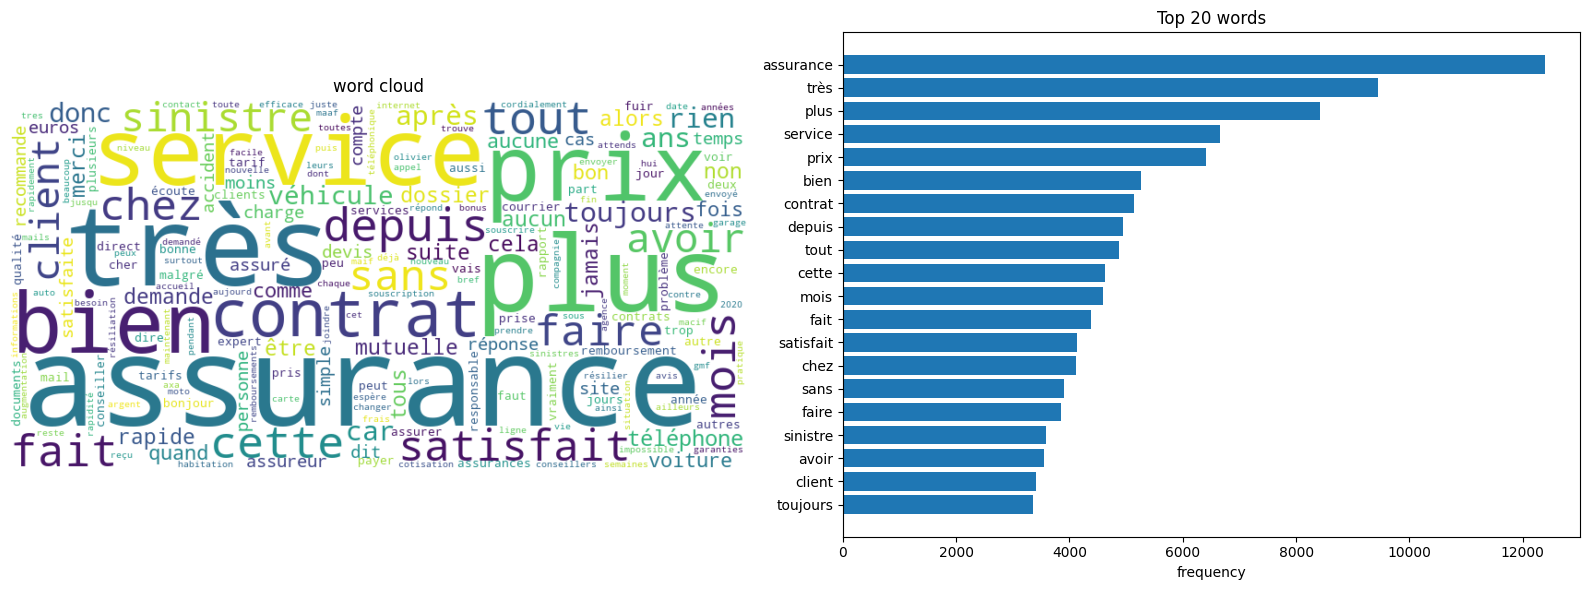

In [ ]:
# Visualize word frequencies using word cloud and bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate and display word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq_filtered)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('word cloud')

# Display top 20 most frequent words as horizontal bar chart
top20 = word_freq_filtered.most_common(20)
words_list, counts = zip(*top20)
axes[1].barh(words_list[::-1], counts[::-1])
axes[1].set_title('Top 20 words')
axes[1].set_xlabel('frequency')

plt.tight_layout()
plt.savefig('word_freq.png', dpi=150)
plt.show()

In [ ]:
# Extract and analyze bigrams and trigrams (word combinations)
from nltk.util import ngrams

# Extract top 10 bigrams (2-word combinations)
bigrams = list(ngrams(words_filtered, 2))
bigram_freq = Counter(bigrams)
print("Top 10 Bigram：")
for bg, count in bigram_freq.most_common(10):
    print(f"{' '.join(bg)}: {count}")

print()

# Extract top 10 trigrams (3-word combinations)
trigrams = list(ngrams(words_filtered, 3))
trigram_freq = Counter(trigrams)
print("Top 10 Trigram：")
for tg, count in trigram_freq.most_common(10):
    print(f"{' '.join(tg)}: {count}")

Top 10 Bigram：
cette assurance: 1742
service client: 1552
direct assurance: 1360
satisfait service: 1285
prise charge: 1018
très bien: 732
très satisfait: 728
aujourd hui: 727
depuis ans: 699
depuis plus: 599

Top 10 Trigram：
rapport qualité prix: 383
depuis plus ans: 350
satisfait service prix: 287
chez direct assurance: 237
bon rapport qualité: 175
recommande cette assurance: 174
très satisfait service: 156
sinistre non responsable: 149
accident non responsable: 148
depuis plusieurs années: 129


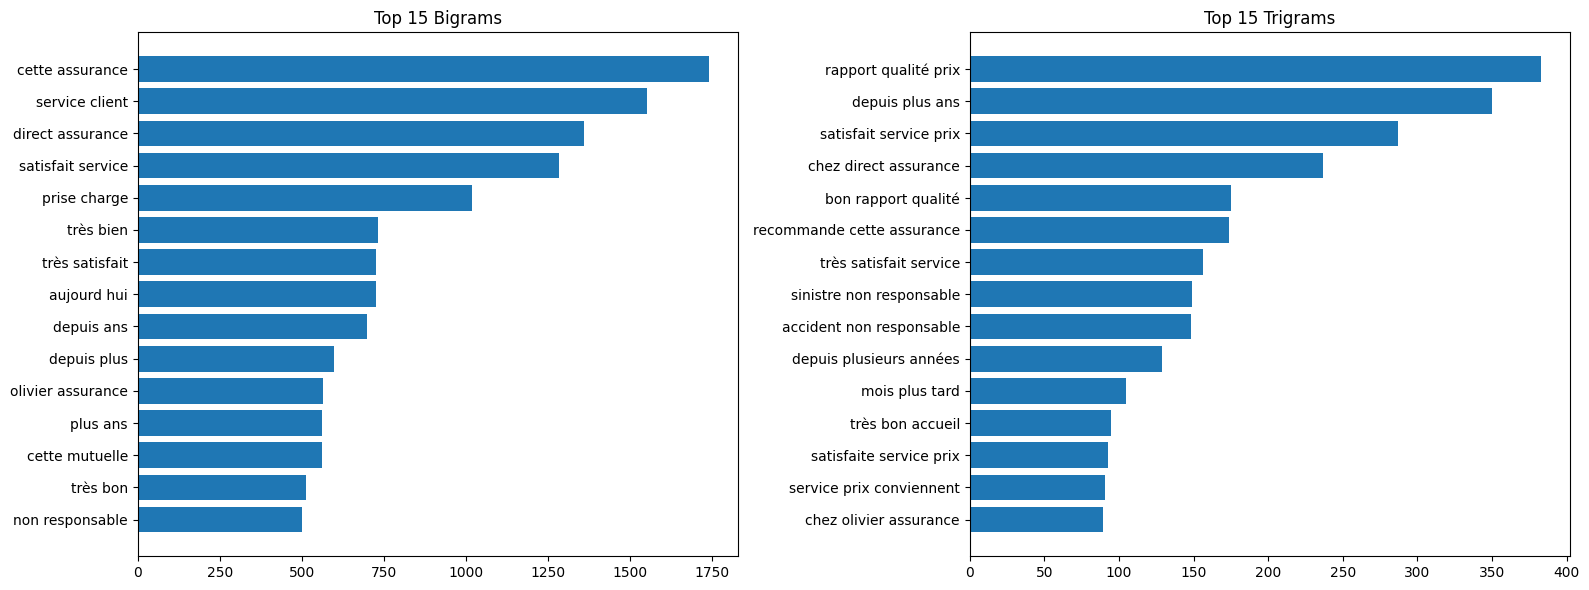

In [ ]:
# Visualize top bigrams and trigrams as horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Display top 15 bigrams
top_bigrams = bigram_freq.most_common(15)
bg_labels, bg_counts = zip(*[(' '.join(bg), c) for bg, c in top_bigrams])
axes[0].barh(bg_labels[::-1], bg_counts[::-1])
axes[0].set_title('Top 15 Bigrams')

# Display top 15 trigrams
top_trigrams = trigram_freq.most_common(15)
tg_labels, tg_counts = zip(*[(' '.join(tg), c) for tg, c in top_trigrams])
axes[1].barh(tg_labels[::-1], tg_counts[::-1])
axes[1].set_title('Top 15 Trigrams')

plt.tight_layout()
plt.savefig('ngram_freq.png', dpi=150)
plt.show()

#### Spelling correction

In [19]:
%pip install symspellpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [symspellpy]
Note: you may need to restart the kernel to use updated packages.


In [21]:
%pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Test spell checker with sample misspelled French words
from spellchecker import SpellChecker

spell = SpellChecker(language='fr')
# Test with misspelled words
test_words = ['assuranse', 'contart', 'servise', 'priz']
for word in test_words:
    corrected = spell.correction(word)
    print(f"{word} -> {corrected}")

assuranse -> assurance
contart -> contact
servise -> service
priz -> pris


In [ ]:
# Apply spell correction to all reviews in the dataset
from tqdm import tqdm
from spellchecker import SpellChecker
corrected_texts = []
for text in tqdm(data_clean['avis_clean']):
    if not text:
        corrected_texts.append(text)
        continue
    words = text.split()
    # Correct each word, keep original if no correction found
    corrected = [spell.correction(w) or w for w in words]
    corrected_texts.append(' '.join(corrected))

data_clean['avis_corrected'] = corrected_texts
print(data_clean[['avis_clean', 'avis_corrected']].head(3))


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24104/24104 [00:16<00:00, 1475.10it/s]

                                             avis_clean  \
2000  les prix au top la facilité d inscription et l...   
2001  je n ai pas les moyens d attendre 3 à 4 semain...   
2002  je voulais assurer une tesla modèle 3 lr le pr...   

                                         avis_corrected  
2000  les prix au top la facilité de inscription et ...  
2001  je un ai pas les moyens de attendre 3 à 4 sema...  
2002  je voulais assurer une testa modèle 3 le le pr...  


In [ ]:
# Save the cleaned and corrected data to CSV
data_clean.to_csv("data_clean.csv", index=False)
print("Saved")

Saved


In [44]:
%pip install transformers==4.35.0

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 7.9 MB/s  0:00:00 eta 0:00:01
  Created wheel for tokenizers: filename=tokenizers-0.14.1-cp313-cp313-macosx_11_0_arm64.whl size=2447980 sha256=2c8117b4f7e0ce0e73419e3ff823144ea879651475a0bd4ae39b0a077b19540c
  Stored in directory: /Users/hanwang/Library/Caches/pip/wheels/94/25/bb/c9f33ac8f2e2aee88fac4d39eb0189247f9131e0001702a04c
Successfully built tokenizers
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.2
    Uninstalling huggingface_hub-1.7.2:
      Successfully uninstalled huggingface_hub-1.7.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers━━━━━━━━━━

## Summary, Translation, and Generation

In [ ]:
# Load the cleaned data and test the BART summarization model
from transformers import pipeline
import pandas as pd
data_clean = pd.read_csv("data_clean.csv")
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Test with a sample English review
long_text = data_clean['avis_en'].dropna().iloc[100]
print("orign: ", long_text[:500])
print()
# Generate a summary with specified length constraints
result = summarizer(long_text, max_length=50, min_length=10, do_sample=False)
print("Summary: ", result[0]['summary_text'])

/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


orign:  hello
I am quite received to see that despite a drastic reduction in the use of specific vehicles in France in 2020 and 2021 (Covid pandemic), the price of insurance premiums has not dropped. It is indisputable that the French have bcp less rolled and that the number of claims has decreased sharply.

Summary:  Despite a drastic reduction in the use of specific vehicles in France in 2020 and 2021, the price of insurance premiums has not dropped. It is indisputable that the French have bcp less rolled and that the number of claims has decreased sharply


In [ ]:
# Check GPU availability for faster processing
import torch
print(torch.cuda.is_available())
print(torch.backends.mps.is_available())  

False
True


In [ ]:
# Summarize all English reviews using the BART model with GPU acceleration
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device="mps")

def summarize_text(text):
    # Skip if text is missing or too short
    if pd.isna(text) or len(text.split()) < 30:
        return text
    try:
        # Truncate to 512 characters (model's max) and generate summary
        result = summarizer(text[:512], max_length=50, min_length=10, do_sample=False)
        return result[0]['summary_text']
    except:
        return text

# Apply summarization to all reviews
data_clean['avis_summary'] = [summarize_text(t) for t in tqdm(data_clean['avis_en'])]
data_clean.to_csv("data_clean.csv", index=False)
print("finish")

  0%|                                                                                                                           | 0/24104 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24104/24104 [10:20:29<00:00,  1.54s/it]


finish


In [4]:
%pip install gensim pyLDAvis

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 22.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 62.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pyLDAvis]3/4 [pyLDAvis]
Note: you may need to restart the kernel to use updated packages.


## Topic Modeling and Lists of Topics:

In [ ]:
# Prepare data for LDA topic modeling: create dictionary and corpus
import gensim
from gensim import corpora
from nltk.corpus import stopwords
import nltk

data_clean = pd.read_csv("data_clean.csv")
french_stopwords = set(stopwords.words('french'))
# Add extra stopwords
extra = {'a', 'l', 'j', 'd', 'qu', 'c', 'm', 'n', 's', 'y'}
french_stopwords.update(extra)

# Preprocess texts: tokenize and filter stopwords
texts = []
for text in data_clean['avis_clean']:
    if isinstance(text, str):
        words = [w for w in text.split() if w not in french_stopwords and len(w) > 2]
        texts.append(words)

# Create dictionary mapping words to IDs and corpus (bag-of-words representation)
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
print(f"Dictionary：{len(dictionary)}")
print(f"Corpus：{len(corpus)}")

Dictionary：31308
Corpus：24104


In [ ]:
# Train LDA model with 10 topics
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10
)

# Display the most important words for each topic
for i, topic in lda_model.print_topics(num_words=8):
    print(f"topic {i}: {topic}")
    print()

topic 0: 0.021*"contrat" + 0.017*"assurance" + 0.013*"mois" + 0.012*"plus" + 0.012*"fait" + 0.010*"cette" + 0.009*"car" + 0.009*"sans"

topic 1: 0.036*"assurance" + 0.034*"plus" + 0.034*"prix" + 0.021*"cher" + 0.016*"moins" + 0.016*"chez" + 0.014*"tarif" + 0.012*"peu"

topic 2: 0.025*"assurance" + 0.018*"sinistre" + 0.015*"voiture" + 0.015*"depuis" + 0.015*"véhicule" + 0.014*"ans" + 0.014*"plus" + 0.011*"expert"

topic 3: 0.021*"toujours" + 0.016*"plus" + 0.016*"mois" + 0.015*"dossier" + 0.014*"service" + 0.014*"depuis" + 0.009*"avoir" + 0.009*"téléphone"

topic 4: 0.053*"mutuelle" + 0.037*"très" + 0.016*"cette" + 0.015*"remboursements" + 0.013*"santé" + 0.012*"toujours" + 0.011*"depuis" + 0.010*"questions"

topic 5: 0.058*"très" + 0.037*"service" + 0.033*"prix" + 0.032*"satisfait" + 0.027*"assurance" + 0.018*"rapide" + 0.017*"merci" + 0.017*"bien"

topic 6: 0.020*"concurrents" + 0.012*"verra" + 0.012*"inutiles" + 0.011*"médecine" + 0.010*"important" + 0.010*"salutations" + 0.008*"cell

In [ ]:
# Visualize LDA topics using pyLDAvis interactive visualization
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()
# Create visualization object
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis, 'lda_visualization.html')
pyLDAvis.display(vis)

In [ ]:
# Save the trained LDA model for future use
lda_model.save("lda_model")
print("saved")

saved


## Embedding to Identify Similar Words

#### Word2Vec Training

In [ ]:
# Train Word2Vec embedding model to capture word semantics
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=texts,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

w2v_model.save("word2vec.model")
print("Vocabulary：", len(w2v_model.wv))

Vocabulary： 16096


In [ ]:
# Find semantically similar words using Word2Vec
for word in ["prix", "service", "sinistre", "remboursement"]:
    similar = w2v_model.wv.most_similar(word, topn=5)
    print(f"\n'{word}' Synonyms:")
    for w, s in similar:
        print(f"  {w}: {s:.4f}")


'prix' Synonyms:
  tarif: 0.8829
  tarifs: 0.8177
  tarification: 0.6861
  marché: 0.6828
  tarifaire: 0.6227

'service' Synonyms:
  relation: 0.6259
  inexistant: 0.5448
  support: 0.5389
  plateforme: 0.5218
  hotline: 0.5021

'sinistre' Synonyms:
  accident: 0.7426
  sinistres: 0.7073
  litige: 0.6901
  incident: 0.6502
  accrochage: 0.6074

'remboursement' Synonyms:
  dentiste: 0.6451
  remboursements: 0.6201
  dentaires: 0.6010
  remboursé: 0.5974
  remboursés: 0.5970


In [ ]:
# Calculate cosine similarity between word pairs
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cosine_dist(word1, word2):
    v1 = w2v_model.wv[word1].reshape(1, -1)
    v2 = w2v_model.wv[word2].reshape(1, -1)
    sim = cosine_similarity(v1, v2)[0][0]
    return sim

# Test cosine similarity on related word pairs
pairs = [("prix", "tarif"), ("sinistre", "accident"), ("service", "client"), ("assurance", "mutuelle")]
for w1, w2 in pairs:
    print(f"cosine({w1}, {w2}) = {cosine_dist(w1, w2):.4f}")

cosine(prix, tarif) = 0.8685
cosine(sinistre, accident) = 0.7542
cosine(service, client) = 0.2029
cosine(assurance, mutuelle) = 0.3155


#### Glove

In [ ]:
# Load pre-trained GloVe embeddings (English word vectors)
import gensim.downloader as api
glove_model = api.load("glove-wiki-gigaword-100")
print("Loaded")

Loaded


In [ ]:
# Find semantically similar English words using GloVe embeddings
for word in ["price", "service", "accident", "insurance", "contract"]:
    similar = glove_model.most_similar(word, topn=5)
    print(f"\n'{word}'Synonyms：")
    for w, s in similar:
        print(f"  {w}: {s:.4f}")


'price'Synonyms：
  prices: 0.8555
  value: 0.7607
  drop: 0.7485
  stock: 0.7451
  market: 0.7408

'service'Synonyms：
  services: 0.8831
  public: 0.6898
  network: 0.6799
  private: 0.6653
  system: 0.6636

'accident'Synonyms：
  crash: 0.8692
  collision: 0.7587
  accidents: 0.7397
  mishap: 0.7299
  explosion: 0.7170

'insurance'Synonyms：
  insurers: 0.8099
  pension: 0.7752
  premiums: 0.7553
  care: 0.7154
  insurer: 0.7120

'contract'Synonyms：
  contracts: 0.8006
  deal: 0.7913
  signed: 0.7303
  agreement: 0.7145
  signing: 0.6951


#### Visualization of embeddings with Matplotlib and Tensorboard

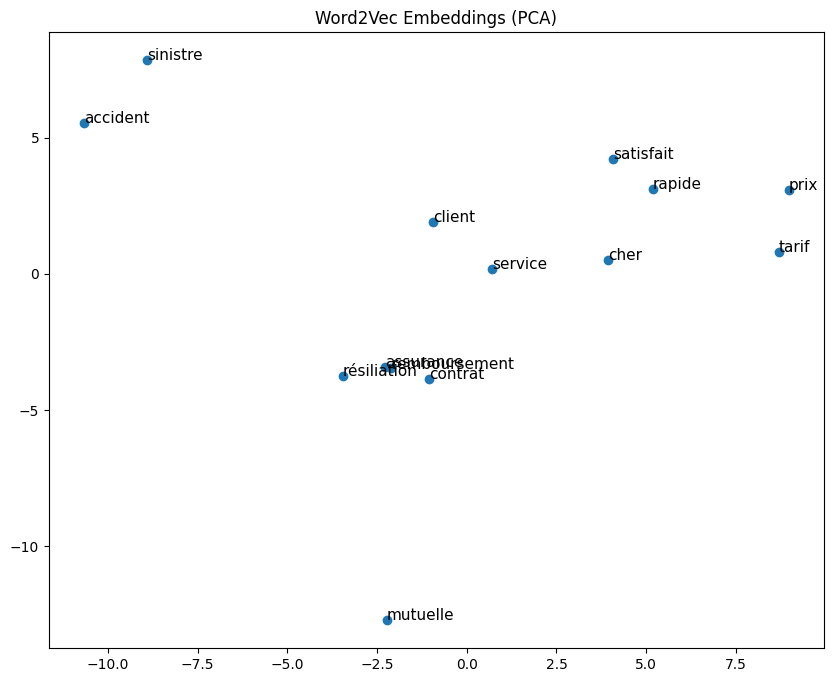

In [ ]:
# Visualize Word2Vec embeddings in 2D using PCA dimensionality reduction
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select representative words related to insurance reviews
words_to_plot = ['prix', 'tarif', 'cher', 'service', 'client', 'sinistre', 
                 'accident', 'remboursement', 'mutuelle', 'assurance', 
                 'satisfait', 'rapide', 'contrat', 'résiliation']

# Extract embeddings for selected words
vectors = np.array([w2v_model.wv[w] for w in words_to_plot])

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot embeddings with labels
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words_to_plot):
    plt.annotate(word, coords[i], fontsize=11)
plt.title('Word2Vec Embeddings (PCA)')
plt.savefig('w2v_pca.png', dpi=150)
plt.show()

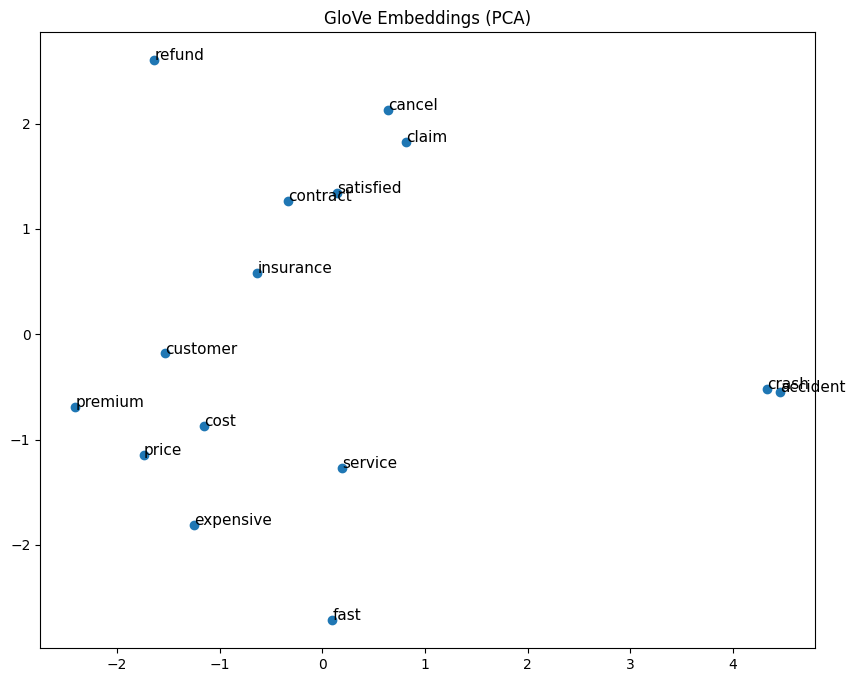

In [ ]:
# Visualize GloVe embeddings in 2D using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select English words for visualization
words_to_plot_en = ['price', 'cost', 'expensive', 'service', 'customer', 
                    'accident', 'crash', 'insurance', 'contract', 'claim',
                    'satisfied', 'fast', 'cancel', 'refund', 'premium']

# Extract GloVe embeddings for selected words
vectors_glove = np.array([glove_model[w] for w in words_to_plot_en])

# Reduce dimensions to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors_glove)

# Plot GloVe embeddings with labels
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words_to_plot_en):
    plt.annotate(word, coords[i], fontsize=11)
plt.title('GloVe Embeddings (PCA)')
plt.savefig('glove_pca.png', dpi=150)
plt.show()

In [15]:
%pip install tensorboard

/opt/miniconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=98334) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Export Word2Vec embeddings to TensorBoard for 3D visualization
import os
import tensorflow as tf
from torch.utils.tensorboard import SummaryWriter
import numpy as np

# Select first 500 words from vocabulary
words_tb = list(w2v_model.wv.index_to_key[:500])
vectors_tb = np.array([w2v_model.wv[w] for w in words_tb])

# Write embeddings to TensorBoard
writer = SummaryWriter('runs/word2vec')
writer.add_embedding(vectors_tb, metadata=words_tb)
writer.close()
print("Finish")

Finish


In [1]:
%load_ext tensorboard

use this command in terminal: tensorboard --logdir runs/word2vec --port 6006（it can not show in the py file, I added the pictures in the final files, and also added other tensorboard's pictures

#### Implementation of Euclidean

In [ ]:
# Calculate Euclidean distances between word pairs for both embeddings
import numpy as np

def euclidean_dist(model, word1, word2):
    v1 = model[word1]
    v2 = model[word2]
    return np.sqrt(np.sum((v1 - v2) ** 2))

# Calculate distances for French words (Word2Vec)
print("Word2Vec Euclidean：")
pairs_fr = [("prix", "tarif"), ("sinistre", "accident"), ("service", "client")]
for w1, w2 in pairs_fr:
    print(f"  euclidean({w1}, {w2}) = {euclidean_dist(w2v_model.wv, w1, w2):.4f}")

# Calculate distances for English words (GloVe)
print("\nGloVe Euclidean：")
pairs_en = [("price", "cost"), ("accident", "crash"), ("insurance", "insurer")]
for w1, w2 in pairs_en:
    print(f"  euclidean({w1}, {w2}) = {euclidean_dist(glove_model, w1, w2):.4f}")

Word2Vec Euclidean：
  euclidean(prix, tarif) = 6.9748
  euclidean(sinistre, accident) = 10.4063
  euclidean(service, client) = 16.0096

GloVe Euclidean：
  euclidean(price, cost) = 4.3513
  euclidean(accident, crash) = 2.9638
  euclidean(insurance, insurer) = 4.5459


#### Semantic Search

In [ ]:
# Prepare corpus vectors for semantic search by averaging word embeddings
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from gensim.models import Word2Vec
w2v_model = Word2Vec.load("word2vec.model")

def get_sentence_vector(text, model):
    # Tokenize and get vectors for words in vocabulary
    words = [w for w in text.split() if w in model.wv]
    if not words:
        return np.zeros(100)
    # Average word vectors to get sentence representation
    return np.mean([model.wv[w] for w in words], axis=0)

# Compute vectors for all reviews in the corpus
corpus_vectors = np.array([get_sentence_vector(text, w2v_model) 
                           for text in data_clean['avis_clean']])
print("shape:", corpus_vectors.shape)

shape: (24104, 100)


In [ ]:
# Implement semantic search to find most similar reviews for a given query
def semantic_search(query, top_n=5):
    # Clean and vectorize the query
    query_clean = query.lower()
    query_vec = get_sentence_vector(query_clean, w2v_model).reshape(1, -1)
    
    # Calculate cosine similarities with all reviews
    similarities = cosine_similarity(query_vec, corpus_vectors)[0]
    # Get indices of top similar reviews
    top_indices = similarities.argsort()[::-1][:top_n]
    
    print(f"find '{query}'\n")
    for i, idx in enumerate(top_indices):
        print(f"num{i+1} (Similarity: {similarities[idx]:.4f})")
        print(f"comment: {data_clean['avis'].iloc[idx][:150]}")
        print(f"star: {data_clean['note'].iloc[idx]}\n")

# Test semantic search
semantic_search("service client horrible impossible joindre")

find 'service client horrible impossible joindre'

num1 (Similarity: 0.8648)
comment: Difficulté de joindre un resposable: La notion du Service est absente:
star: 2

num2 (Similarity: 0.8434)
comment: Service client défectueux
Rachats très longs
Impossible de joindre l Afer au téléphone
Choix des UC trop restreint
star: 2

num3 (Similarity: 0.8412)
comment: Le service client est une catastrophe. Il est impossible de joindre un responsable en ligne. Il s'agit de call center basé à l'étranger qui ne peut ab
star: 1

num4 (Similarity: 0.8342)
comment: Impossible de les joindre par telephone, attente interminable. espace client ne marche pas, donc impossible d’avoir une validation de devis. juste l’h
star: 1

num5 (Similarity: 0.8326)
comment: Impossible de joindre le service en cas de sinistre. Une gestion volontairement absente. un enfer!
star: 1



## Supervised Learning

#### TF-IDF and classical ML

In [ ]:
# Convert reviews to TF-IDF features and split into train/test sets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd
data_clean = pd.read_csv("data_clean.csv")

# Prepare features and labels
X = data_clean['avis_clean']
y = data_clean['note']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to TF-IDF feature vectors
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

Train size: (19283, 10000)
Test size: (4821, 10000)


In [ ]:
# Train and compare three classical machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: accuracy = {acc:.4f}")

Logistic Regression: accuracy = 0.5291
LinearSVC: accuracy = 0.4976
Naive Bayes: accuracy = 0.5235


In [ ]:
# Generate detailed classification report for best model (Logistic Regression)
best_model = models["Logistic Regression"]
y_pred = best_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=["1star","2star","3star","4star","5star"]))

              precision    recall  f1-score   support

       1star       0.61      0.86      0.72      1465
       2star       0.36      0.18      0.24       735
       3star       0.36      0.18      0.24       672
       4star       0.45      0.45      0.45       972
       5star       0.56      0.61      0.58       977

    accuracy                           0.53      4821
   macro avg       0.47      0.46      0.45      4821
weighted avg       0.49      0.53      0.50      4821



#### Basic model with embedding laye

In [ ]:
# Save trained models and vectorizer for future inference
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open("tfidf_lr_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("Saved")

Saved


In [9]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Tokenize reviews and convert to sequences for deep learning models
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 200

# Fit tokenizer on training data
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences and pad to same length
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

# Convert labels to 0-indexed for neural networks
y_train_cat = np.array(y_train) - 1
y_test_cat = np.array(y_test) - 1

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)

X_train_seq shape: (19283, 200)
X_test_seq shape: (4821, 200)


In [ ]:
# Build deep learning model with embedding layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model_emb = Sequential([
    # Embedding layer: convert word indices to dense vectors
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    # Pool embeddings to get sentence representation
    GlobalAveragePooling1D(),
    # Dense layers with ReLU activation
    Dense(64, activation='relu'),
    # Output layer with softmax for 5-class classification
    Dense(5, activation='softmax')
])

model_emb.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_emb.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the embedding model with early stopping via validation
history = model_emb.fit(
    X_train_seq, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3974 - loss: 1.4135 - val_accuracy: 0.4759 - val_loss: 1.2836
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4693 - loss: 1.2160 - val_accuracy: 0.5013 - val_loss: 1.1529
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4881 - loss: 1.1366 - val_accuracy: 0.5054 - val_loss: 1.1086
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5047 - loss: 1.0956 - val_accuracy: 0.5054 - val_loss: 1.1049
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5107 - loss: 1.0783 - val_accuracy: 0.4899 - val_loss: 1.1517


In [ ]:
# Evaluate embedding model on test set
from sklearn.metrics import accuracy_score, classification_report

# Get predictions and convert from one-hot to class labels
y_pred_emb = np.argmax(model_emb.predict(X_test_seq), axis=1)
acc = accuracy_score(y_test_cat, y_pred_emb)
print(f"Embedding model accuracy: {acc:.4f}")
print(classification_report(y_test_cat, y_pred_emb, target_names=["1star","2star","3star","4star","5star"]))

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step
Embedding model accuracy: 0.4833
              precision    recall  f1-score   support

       1star       0.53      0.97      0.68      1465
       2star       0.36      0.03      0.05       735
       3star       0.25      0.16      0.20       672
       4star       0.41      0.38      0.39       972
       5star       0.56      0.42      0.48       977

    accuracy                           0.48      4821
   macro avg       0.42      0.39      0.36      4821
weighted avg       0.45      0.48      0.42      4821



In [ ]:
# Save embedding model and export embeddings to TensorBoard
model_emb.save("embedding_model.keras")

# TensorBoard embedding visualization
from torch.utils.tensorboard import SummaryWriter
import numpy as np

# Extract embedding weights from first layer
embedding_weights = model_emb.layers[0].get_weights()[0]
words_tb = list(tokenizer.word_index.keys())[:500]
indices = [tokenizer.word_index[w] for w in words_tb]
vectors_tb = embedding_weights[indices]

# Write to TensorBoard
writer = SummaryWriter('runs/embedding_model')
import torch
writer.add_embedding(torch.tensor(vectors_tb), metadata=words_tb)
writer.close()
print("Saved")

Saved


use this command in terminal： tensorboard --logdir runs/embedding_model --port 6007

#### Model with pre-trained embeddings

In [ ]:
# Create embedding matrix using pre-trained Word2Vec vectors
import numpy as np
from gensim.models import Word2Vec

w2v_model = Word2Vec.load("word2vec.model")
embedding_dim = 100
# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((MAX_WORDS, embedding_dim))

# Fill matrix with Word2Vec vectors for words in vocabulary
for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS and word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


In [ ]:
# Build model with pre-trained embeddings (non-trainable)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model_pretrained = Sequential([
    # Use pre-trained Word2Vec embeddings, frozen (non-trainable)
    Embedding(input_dim=MAX_WORDS, output_dim=100, 
              weights=[embedding_matrix], 
              input_length=MAX_LEN, 
              trainable=False),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_pretrained.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_pretrained.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
# Train the pre-trained embedding model
history_pretrained = model_pretrained.fit(
    X_train_seq, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4706 - loss: 1.2632 - val_accuracy: 0.4982 - val_loss: 1.1414
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.5080 - loss: 1.1242 - val_accuracy: 0.5091 - val_loss: 1.1076
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.5156 - loss: 1.1026 - val_accuracy: 0.5200 - val_loss: 1.0948
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.5224 - loss: 1.0907 - val_accuracy: 0.5194 - val_loss: 1.0887
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.5237 - loss: 1.0838 - val_accuracy: 0.5210 - val_loss: 1.0833


In [ ]:
# Evaluate pre-trained embedding model on test set
y_pred_pretrained = np.argmax(model_pretrained.predict(X_test_seq), axis=1)
acc = accuracy_score(y_test_cat, y_pred_pretrained)
print(f"Pre-trained embedding model accuracy: {acc:.4f}")
print(classification_report(y_test_cat, y_pred_pretrained, target_names=["1star","2star","3star","4star","5star"]))

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step
Pre-trained embedding model accuracy: 0.5250
              precision    recall  f1-score   support

       1star       0.59      0.90      0.71      1465
       2star       0.39      0.07      0.12       735
       3star       0.36      0.10      0.15       672
       4star       0.42      0.50      0.46       972
       5star       0.56      0.62      0.59       977

    accuracy                           0.52      4821
   macro avg       0.46      0.44      0.40      4821
weighted avg       0.48      0.52      0.47      4821



In [ ]:
# Save pre-trained model and export embeddings to TensorBoard
model_pretrained.save("pretrained_embedding_model.keras")

# TensorBoard visualization
from torch.utils.tensorboard import SummaryWriter
import torch

# Extract pre-trained embeddings
embedding_weights_pt = model_pretrained.layers[0].get_weights()[0]
words_tb = list(tokenizer.word_index.keys())[:500]
indices = [tokenizer.word_index[w] for w in words_tb]
vectors_tb = embedding_weights_pt[indices]

# Write to TensorBoard
writer = SummaryWriter('runs/pretrained_embedding')
writer.add_embedding(torch.tensor(vectors_tb), metadata=words_tb)
writer.close()
print("Saved")

Saved


use this command in terminal： tensorboard --logdir runs/pretrained_embedding --port 6008

#### USE (Universal Sentence Embedding) or equivalents, RNN LSTM, CNN, BERT, or other models on Hugging Face( I choose CNN, it is much faster)

In [ ]:
# Build CNN model with convolutional layers for text classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model_cnn = Sequential([
    # Embedding layer
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    # 1D convolution to extract local features (n-grams)
    Conv1D(128, 5, activation='relu'),
    # Pool over time dimension
    GlobalMaxPooling1D(),
    # Dense layer with dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.5),
    # Output layer
    Dense(5, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model
history_cnn = model_cnn.fit(
    X_train_seq, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4378 - loss: 1.2933 - val_accuracy: 0.5168 - val_loss: 1.0865
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5115 - loss: 1.0744 - val_accuracy: 0.5174 - val_loss: 1.0612
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5591 - loss: 0.9818 - val_accuracy: 0.5231 - val_loss: 1.0751
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6047 - loss: 0.8943 - val_accuracy: 0.5298 - val_loss: 1.1276
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6668 - loss: 0.7842 - val_accuracy: 0.5054 - val_loss: 1.2144


In [ ]:
# Evaluate CNN model on test set
y_pred_cnn = np.argmax(model_cnn.predict(X_test_seq), axis=1)
acc = accuracy_score(y_test_cat, y_pred_cnn)
print(f"CNN model accuracy: {acc:.4f}")
print(classification_report(y_test_cat, y_pred_cnn, target_names=["1star","2star","3star","4star","5star"]))

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN model accuracy: 0.5078
              precision    recall  f1-score   support

       1star       0.66      0.71      0.68      1465
       2star       0.34      0.34      0.34       735
       3star       0.33      0.20      0.25       672
       4star       0.42      0.40      0.41       972
       5star       0.54      0.66      0.59       977

    accuracy                           0.51      4821
   macro avg       0.46      0.46      0.45      4821
weighted avg       0.49      0.51      0.50      4821



In [ ]:
# Save trained CNN model
model_cnn.save("cnn_model.keras")
print("Saved")

Saved


#### LLM

In [ ]:
# Test zero-shot classification for sentiment analysis
from transformers import pipeline

# Load zero-shot classifier from Hugging Face
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Test samples with different sentiments
test_reviews = [
    "Service excellent, très satisfait, je recommande vivement!",
    "Horrible, impossible de les contacter, arnaque totale.",
    "Correct sans plus, rien d'exceptionnel."
]

# Define sentiment labels
labels = ["very positive", "positive", "neutral", "negative", "very negative"]

# Classify each review
for review in test_reviews:
    result = classifier(review, labels)
    print(f"Review: {review[:60]}")
    print(f"Prediction: {result['labels'][0]}\n")

/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Review: Service excellent, très satisfait, je recommande vivement!
Prediction: positive

Review: Horrible, impossible de les contacter, arnaque totale.
Prediction: negative

Review: Correct sans plus, rien d'exceptionnel.
Prediction: positive



#### Comparison of different models

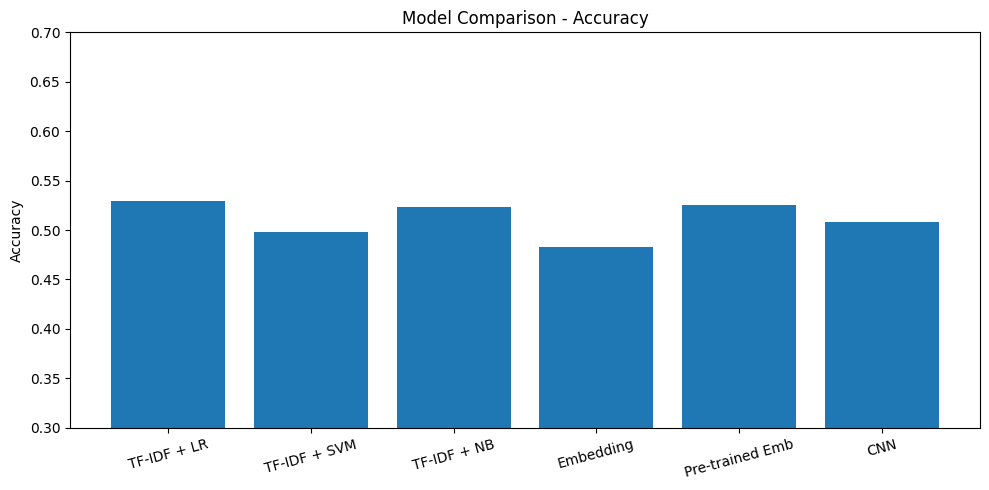

In [ ]:
# Compare accuracy of different models with visualization
import matplotlib.pyplot as plt

# Accuracy scores from trained models
models_comparison = {
    "TF-IDF + LR": 0.5291,
    "TF-IDF + SVM": 0.4976,
    "TF-IDF + NB": 0.5235,
    "Embedding": 0.4833,
    "Pre-trained Emb": 0.5250,
    "CNN": 0.5078
}

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(models_comparison.keys(), models_comparison.values())
plt.ylim(0.3, 0.7)
plt.title("Model Comparison - Accuracy")
plt.xticks(rotation=15)
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

In [ ]:
# Convert numerical ratings to sentiment categories
def note_to_sentiment(note):
    if note <= 2:
        return "negative"
    elif note == 3:
        return "neutral"
    else:
        return "positive"

# Add sentiment column
data_clean['sentiment'] = data_clean['note'].apply(note_to_sentiment)
print(data_clean['sentiment'].value_counts())

sentiment
negative    10987
positive     9735
neutral      3382
Name: count, dtype: int64


In [ ]:
# Train sentiment classifier (3-class: negative, neutral, positive)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Get sentiment labels for train and test sets
y_sentiment_train = data_clean.loc[X_train.index, 'sentiment']
y_sentiment_test = data_clean.loc[X_test.index, 'sentiment']

# Train logistic regression on TF-IDF features
sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train_tfidf, y_sentiment_train)

# Evaluate
y_pred_sentiment = sentiment_model.predict(X_test_tfidf)
print(f"Sentiment accuracy: {accuracy_score(y_sentiment_test, y_pred_sentiment):.4f}")
print(classification_report(y_sentiment_test, y_pred_sentiment))

Sentiment accuracy: 0.8154
              precision    recall  f1-score   support

    negative       0.83      0.95      0.89      2200
     neutral       0.39      0.08      0.14       672
    positive       0.82      0.92      0.87      1949

    accuracy                           0.82      4821
   macro avg       0.68      0.65      0.63      4821
weighted avg       0.77      0.82      0.78      4821



In [ ]:
# Save trained sentiment model for production use
import pickle
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(sentiment_model, f)
print("Saved")

Saved


## Results Interpretation

#### Error analysis

In [ ]:
# Load saved models and data for error analysis
import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

data_clean = pd.read_csv("data_clean.csv")

# Prepare data
X = data_clean['avis_clean']
y = data_clean['note']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load trained models
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)
with open("tfidf_lr_model.pkl", "rb") as f:
    best_model = pickle.load(f)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

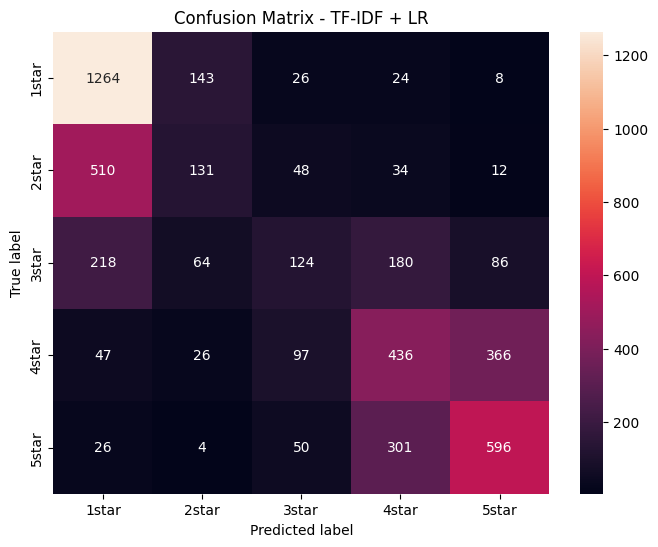

In [ ]:
# Generate and visualize confusion matrix for error analysis
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_lr = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=["1star","2star","3star","4star","5star"],
            yticklabels=["1star","2star","3star","4star","5star"])
plt.title("Confusion Matrix - TF-IDF + LR")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# Analyze misclassified reviews to identify error patterns
y_pred_lr = best_model.predict(X_test_tfidf)
X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

# Collect all misclassified examples
errors = []
for text, true, pred in zip(X_test_list, y_test_list, y_pred_lr):
    if true != pred:
        errors.append({'text': text[:150], 'true_label': int(true), 'predicted': int(pred)})

error_df = pd.DataFrame(errors)
print(f"Total errors: {len(error_df)} / {len(y_test_list)}")
print(f"Error rate: {len(error_df)/len(y_test_list):.2%}\n")

# Analyze most common error patterns
error_df['error_type'] = error_df['true_label'].astype(str) + " -> " + error_df['predicted'].astype(str)
print(error_df['error_type'].value_counts().head(10))

Total errors: 2270 / 4821
Error rate: 47.09%

error_type
2 -> 1    510
4 -> 5    366
5 -> 4    301
3 -> 1    218
3 -> 4    180
1 -> 2    143
4 -> 3     97
3 -> 5     86
3 -> 2     64
5 -> 3     50
Name: count, dtype: int64


#### Sentiment detection

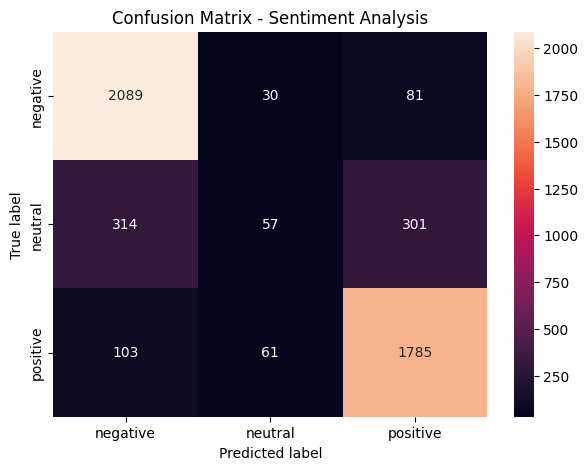

In [ ]:
# Generate confusion matrix for sentiment classification
with open("sentiment_model.pkl", "rb") as f:
    sentiment_model = pickle.load(f)

def note_to_sentiment(note):
    if note <= 2:
        return "negative"
    elif note == 3:
        return "neutral"
    else:
        return "positive"

# Get sentiment predictions
data_clean['sentiment'] = data_clean['note'].apply(note_to_sentiment)
y_sentiment_test = data_clean.loc[X_test.index, 'sentiment']
y_pred_sentiment = sentiment_model.predict(X_test_tfidf)

# Create and plot confusion matrix
cm_sentiment = confusion_matrix(y_sentiment_test, y_pred_sentiment, labels=["negative","neutral","positive"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_sentiment, annot=True, fmt='d',
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.title("Confusion Matrix - Sentiment Analysis")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.savefig("confusion_matrix_sentiment.png", dpi=150)
plt.show()

#### Classical models with themes

In [ ]:
# Classify reviews by theme using zero-shot classification
from transformers import pipeline

# Load zero-shot classifier
theme_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Define insurance-related themes
labels = ["pricing", "customer service", "coverage", "claims processing", "cancellation", "enrollment"]

# Test on sample reviews
samples = data_clean['avis_en'].dropna().head(5).tolist()
for text in samples:
    result = theme_classifier(text[:200], labels)
    print(f"Text: {text[:80]}")
    print(f"Theme: {result['labels'][0]}\n")

/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Text: top prices, ease of registration and clear services offered
I easily recommend t
Theme: coverage

Text: I cannot afford to wait 3 to 4 weeks for reimbursement; As for the broker it onl
Theme: coverage

Text: I wanted to ensure a Tesla Model 3 LR ...
The price of insurance any risk offere
Theme: pricing

Text: I am on work stoppage since Nov 2017, assured Cardifff in the event of illness, 
Theme: cancellation

Text: Inadmissible ... I set them too perceived following an error of my dentist on ca
Theme: claims processing



In [ ]:
# Classify first 1000 reviews by theme and analyze rating by theme
from tqdm import tqdm

sample_data = data_clean[data_clean['avis_en'].notna()].head(1000).copy()

# Classify each review
themes = []
for text in tqdm(sample_data['avis_en']):
    result = theme_classifier(text[:200], labels)
    themes.append(result['labels'][0])

sample_data['theme'] = themes

# Calculate average rating for each theme
theme_stats = sample_data.groupby('theme')['note'].agg(['mean', 'count'])
print(theme_stats.sort_values('mean'))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [15:49<00:00,  1.05it/s]

                       mean  count
theme                             
cancellation       1.469136     81
claims processing  1.696970     33
coverage           2.511936    377
enrollment         2.625000     16
pricing            3.105932    236
customer service   3.533074    257


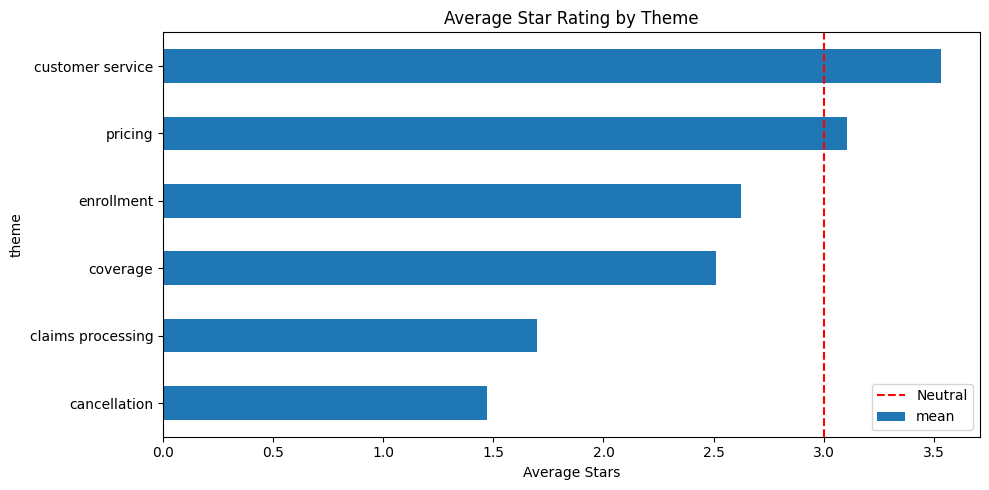

In [ ]:
# Visualize average rating by theme
plt.figure(figsize=(10, 5))
theme_stats['mean'].sort_values().plot(kind='barh')
plt.title("Average Star Rating by Theme")
plt.xlabel("Average Stars")
# Add reference line for neutral rating
plt.axvline(x=3, color='red', linestyle='--', label='Neutral')
plt.legend()
plt.tight_layout()
plt.savefig("theme_analysis.png", dpi=150)
plt.show()

#### Deep learning models for words

In [ ]:
# Load and retrain CNN model for demonstration
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000
MAX_LEN = 200

# Prepare tokenized sequences
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

# Convert labels to 0-indexed
y_train_cat = np.array(y_train) - 1
y_test_cat = np.array(y_test) - 1

# Load and train CNN model
model_cnn = load_model("cnn_model.keras")
history_cnn = model_cnn.fit(
    X_train_seq, y_train_cat,
    epochs=5, batch_size=64,
    validation_split=0.1, verbose=1
)

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7297 - loss: 0.6650 - val_accuracy: 0.4868 - val_loss: 1.3440
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7971 - loss: 0.5414 - val_accuracy: 0.4951 - val_loss: 1.5251
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8488 - loss: 0.4220 - val_accuracy: 0.4717 - val_loss: 1.8124
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8891 - loss: 0.3261 - val_accuracy: 0.4764 - val_loss: 2.1088
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9190 - loss: 0.2481 - val_accuracy: 0.4738 - val_loss: 2.3578


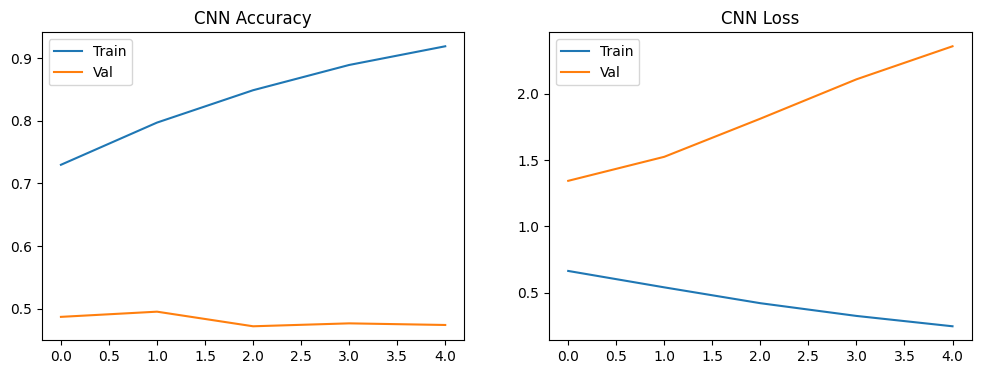

In [ ]:
# Plot CNN training history (accuracy and loss curves)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Val')
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Val')
plt.title("CNN Loss")
plt.legend()

plt.savefig("cnn_training.png", dpi=150)
plt.show()

## Creation of Streamlit applications

In [ ]:
%%%writefile app.py
# Streamlit application for insurance review analysis and prediction

import streamlit as st
import pandas as pd
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Load trained models and data
@st.cache_resource
def load_models():
    with open("tfidf_vectorizer.pkl", "rb") as f:
        vectorizer = pickle.load(f)
    with open("tfidf_lr_model.pkl", "rb") as f:
        star_model = pickle.load(f)
    with open("sentiment_model.pkl", "rb") as f:
        sentiment_model = pickle.load(f)
    return vectorizer, star_model, sentiment_model

@st.cache_data
def load_data():
    return pd.read_csv("data_clean.csv")

def clean_text(text):
    # Apply same preprocessing as training data
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load data and models
vectorizer, star_model, sentiment_model = load_models()
data = load_data()

st.title("Insurance Review Analyzer")

# Sidebar navigation
page = st.sidebar.selectbox("Choose a page", ["Prediction", "Summary", "Explanation", "Information Retrieval", "RAG", "QA"])

if page == "Prediction":
    st.header("Predict Star Rating & Sentiment")
    user_input = st.text_area("Enter your review:", height=150)
    if st.button("Predict"):
        if user_input:
            # Preprocess and predict
            cleaned = clean_text(user_input)
            tfidf = vectorizer.transform([cleaned])
            star = star_model.predict(tfidf)[0]
            sentiment = sentiment_model.predict(tfidf)[0]
            st.success(f"Predicted Stars: {int(star)} / 5")
            st.info(f"Sentiment: {sentiment}")
        else:
            st.warning("Please enter a review.")

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 4.0 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 8.1 MB/s  0:00:00
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 3.9 MB/s  0:00:02m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 3.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 3.1 MB/s  0:00:10m0:00:0100:01
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
  Attempting uninstall: pandas━━╺━━━━━━━━━━━━━━━  9/15 [pydeck]s]
    Found existing installation: pandas 3.0.00m━━━━━━━━━━━━━━━  9/15 [pydeck]
    Uninstalling pandas-3.0.0:0m╺━━━━━━━━━━━━━━━  9/15 [py

#### Prediction

In [ ]:
%%writefile app.py
# Complete Streamlit application for insurance review analysis

import streamlit as st
import pandas as pd
import pickle
import numpy as np
import re

# Load models and data with caching
@st.cache_resource
def load_models():
    with open("tfidf_vectorizer.pkl", "rb") as f:
        vectorizer = pickle.load(f)
    with open("tfidf_lr_model.pkl", "rb") as f:
        star_model = pickle.load(f)
    with open("sentiment_model.pkl", "rb") as f:
        sentiment_model = pickle.load(f)
    return vectorizer, star_model, sentiment_model

@st.cache_data
def load_data():
    return pd.read_csv("data_clean.csv")

def clean_text(text):
    # Apply text cleaning: lowercase, remove special chars, normalize spaces
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load resources
vectorizer, star_model, sentiment_model = load_models()
data = load_data()

st.title("Insurance Review Analyzer")
page = st.sidebar.selectbox("Choose a page", ["Prediction", "Summary", "Explanation", "Information Retrieval", "RAG", "QA"])

if page == "Prediction":
    st.header("Predict Star Rating & Sentiment")
    user_input = st.text_area("Enter your review:", height=150)
    if st.button("Predict"):
        if user_input:
            cleaned = clean_text(user_input)
            tfidf = vectorizer.transform([cleaned])
            star = star_model.predict(tfidf)[0]
            sentiment = sentiment_model.predict(tfidf)[0]
            st.success(f"Predicted Stars: {int(star)} / 5")
            st.info(f"Sentiment: {sentiment}")
        else:
            st.warning("Please enter a review.")

elif page == "Summary":
    st.header("Review Summary by Insurer")
    insurer = st.selectbox("Select an insurer:", data['assureur'].unique())
    insurer_data = data[data['assureur'] == insurer]
    st.write(f"Total reviews: {len(insurer_data)}")
    st.write(f"Average rating: {insurer_data['note'].mean():.2f} / 5")
    st.subheader("Recent reviews summary:")
    samples = insurer_data['avis_summary'].dropna().head(5).tolist()
    for i, s in enumerate(samples):
        st.write(f"{i+1}. {s}")
    st.subheader("Rating distribution:")
    st.bar_chart(insurer_data['note'].value_counts().sort_index())

elif page == "Explanation":
    st.header("Prediction Explanation")
    user_input = st.text_area("Enter your review:", height=150)
    if st.button("Explain"):
        if user_input:
            cleaned = clean_text(user_input)
            tfidf = vectorizer.transform([cleaned])
            star = star_model.predict(tfidf)[0]
            sentiment = sentiment_model.predict(tfidf)[0]
            st.success(f"Predicted Stars: {int(star)} / 5")
            st.info(f"Sentiment: {sentiment}")
            # Show top influential features
            feature_names = vectorizer.get_feature_names_out()
            tfidf_array = tfidf.toarray()[0]
            top_indices = tfidf_array.argsort()[::-1][:10]
            top_words = [(feature_names[i], tfidf_array[i]) for i in top_indices if tfidf_array[i] > 0]
            st.subheader("Most influential words:")
            for word, score in top_words:
                st.write(f"**{word}**: {score:.4f}")
        else:
            st.warning("Please enter a review.")

elif page == "Information Retrieval":
    st.header("Search Reviews")
    query = st.text_input("Enter keywords to search:")
    star_filter = st.multiselect("Filter by stars:", [1, 2, 3, 4, 5], default=[1,2,3,4,5])
    if st.button("Search"):
        if query:
            filtered = data[data['note'].isin(star_filter)]
            results = filtered[filtered['avis'].str.contains(query, case=False, na=False)]
            st.write(f"Found {len(results)} reviews")
            for _, row in results.head(10).iterrows():
                st.write(f"**{int(row['note'])} stars** | {row['assureur']}")
                st.write(row['avis'][:200])
                st.divider()
        else:
            st.warning("Please enter a keyword.")

elif page == "RAG":
    st.header("RAG - Ask about Insurers")
    query = st.text_input("Ask a question about insurance reviews:")
    if st.button("Search & Answer"):
        if query:
            # Find relevant reviews using keyword search
            results = data[data['avis'].str.contains(query, case=False, na=False)]
            context = " ".join(results['avis_en'].dropna().head(5).tolist())
            st.subheader("Relevant reviews found:")
            for _, row in results.head(3).iterrows():
                st.write(f"**{int(row['note'])} stars** | {row['assureur']}")
                st.write(row['avis'][:200])
                st.divider()
            st.subheader("Context summary:")
            st.write(context[:500])
        else:
            st.warning("Please enter a question.")

elif page == "QA":
    st.header("Q&A about Insurers")
    insurer = st.selectbox("Select an insurer:", data['assureur'].unique())
    question = st.text_input("Ask a question:")
    if st.button("Answer"):
        if question:
            insurer_data = data[data['assureur'] == insurer]
            avg_rating = insurer_data['note'].mean()
            total = len(insurer_data)
            positive = len(insurer_data[insurer_data['note'] >= 4])
            negative = len(insurer_data[insurer_data['note'] <= 2])
            
            st.write(f"**Insurer:** {insurer}")
            st.write(f"**Total reviews:** {total}")
            st.write(f"**Average rating:** {avg_rating:.2f} / 5")
            st.write(f"**Positive reviews (4-5 stars):** {positive} ({positive/total*100:.1f}%)")
            st.write(f"**Negative reviews (1-2 stars):** {negative} ({negative/total*100:.1f}%)")
            
            st.subheader("Sample reviews:")
            samples = insurer_data.sample(min(3, len(insurer_data)))
            for _, row in samples.iterrows():
                st.write(f"**{int(row['note'])} stars:** {row['avis'][:150]}")
                st.divider()
        else:
            st.warning("Please enter a question.")

Overwriting app.py


And we use the command below to run the app:
streamlit run app.py